In [1]:
!pip -q install transformers timm pandas matplotlib


In [2]:
from pathlib import Path
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel

try:
    from torch.utils.flop_counter import FlopCounterMode
except Exception as e:
    raise RuntimeError("Need a PyTorch version with FlopCounterMode.") from e

REPO_DIR = "/path/to/VECA"

RESOLUTIONS = [256, 384, 512, 768, 1024]
MODEL_SIZES = ["small", "base", "large"]
ACTIVE_K = 64
FLOPS_BATCH = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else None

DINO_IDS = {
    "small": "facebook/dinov3-vits16-pretrain-lvd1689m",
    "base": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "large": "facebook/dinov3-vitl16-pretrain-lvd1689m",
}

sys.path.insert(0, REPO_DIR)
device = torch.device(DEVICE)
print("device:", device)


device: cuda


In [3]:
from veca.model import VECA
from veca.config import MultiResFinetuneConfig, normalize_nested_settings

def get_flops(model, x):
    model.eval()
    counter = FlopCounterMode(display=False, depth=None)
    with torch.inference_mode(), counter:
        if x.is_cuda and DTYPE is not None:
            with torch.autocast(device_type="cuda", dtype=DTYPE):
                _ = model(x)
        else:
            _ = model(x)
    return int(counter.get_total_flops())

def find_attention_modules(model):
    out = []
    for name, module in model.named_modules():
        has_qkv = all(hasattr(module, k) for k in ["q_proj", "k_proj", "v_proj"])
        has_out = hasattr(module, "out_proj") or hasattr(module, "o_proj")
        if has_qkv and has_out:
            out.append((name, module))
    return out

def get_out_proj(attn):
    return attn.out_proj if hasattr(attn, "out_proj") else attn.o_proj

def teacher_num_heads(model, attn):
    if hasattr(attn, "num_heads"):
        return int(attn.num_heads)
    return int(model.config.num_attention_heads)

def teacher_patch_size(model):
    ps = getattr(model.config, "patch_size", 16)
    return int(ps[0] if isinstance(ps, (tuple, list)) else ps)

def teacher_registers(model):
    return int(getattr(model.config, "num_register_tokens", 0) or 0)


In [4]:
class VecaSingleMaskedAttention(nn.Module):
    def __init__(self, attn, active_k):
        super().__init__()
        self.active_k = int(active_k)
        self.num_heads = int(attn.num_heads)
        self.dim = int(attn.q_proj.out_features)
        self.head_dim = self.dim // self.num_heads

        self.q_proj = attn.q_proj
        self.k_proj = attn.k_proj
        self.v_proj = attn.v_proj
        self.out_proj = get_out_proj(attn)

    def forward(self, x):
        B, N, D = x.shape
        H, Hd = self.num_heads, self.head_dim
        K = self.active_k

        q = self.q_proj(x).view(B, N, H, Hd).transpose(1, 2)
        k = self.k_proj(x).view(B, N, H, Hd).transpose(1, 2)
        v = self.v_proj(x).view(B, N, H, Hd).transpose(1, 2)

        out_q = F.scaled_dot_product_attention(q[:, :, :K], k, v, dropout_p=0.0)
        out_p = F.scaled_dot_product_attention(q[:, :, K:], k[:, :, :K], v[:, :, :K], dropout_p=0.0)

        out = torch.cat([out_q, out_p], dim=2)
        out = out.transpose(1, 2).contiguous().view(B, N, D)
        return self.out_proj(out)

class DinoSingleFullAttention(nn.Module):
    def __init__(self, teacher, attn):
        super().__init__()
        self.q_proj = attn.q_proj
        self.k_proj = attn.k_proj
        self.v_proj = attn.v_proj
        self.out_proj = get_out_proj(attn)

        self.num_heads = teacher_num_heads(teacher, attn)
        self.dim = int(self.q_proj.out_features)
        self.head_dim = self.dim // self.num_heads

    def forward(self, x):
        B, N, D = x.shape
        H, Hd = self.num_heads, self.head_dim

        q = self.q_proj(x).view(B, N, H, Hd).transpose(1, 2)
        k = self.k_proj(x).view(B, N, H, Hd).transpose(1, 2)
        v = self.v_proj(x).view(B, N, H, Hd).transpose(1, 2)

        out = F.scaled_dot_product_attention(q, k, v, dropout_p=0.0)
        out = out.transpose(1, 2).contiguous().view(B, N, D)
        return self.out_proj(out)


In [7]:
rows = []

for size in MODEL_SIZES:
    print("model size:", size)

    cfg = MultiResFinetuneConfig()
    cfg.model_family = size
    cfg.init_patch_from_dinov3 = False
    normalize_nested_settings(cfg)

    veca = VECA(cfg).to(device).eval()
    veca_attn = veca.blocks[0].attn
    veca_single = VecaSingleMaskedAttention(veca_attn, ACTIVE_K).to(device).eval()

    dino = AutoModel.from_pretrained(DINO_IDS[size]).to(device).eval()
    dino_attn = find_attention_modules(dino)[0][1]
    dino_single = DinoSingleFullAttention(dino, dino_attn).to(device).eval()

    veca_patch = int(cfg.patch_size)
    dino_patch = teacher_patch_size(dino)
    dino_regs = teacher_registers(dino)

    for res in RESOLUTIONS:
        if res % veca_patch != 0 or res % dino_patch != 0:
            continue

        n_veca = (res // veca_patch) ** 2
        n_dino = (res // dino_patch) ** 2

        seq_veca = ACTIVE_K + n_veca
        seq_dino = 1 + dino_regs + n_dino

        x_veca = torch.randn(FLOPS_BATCH, seq_veca, cfg.hidden_dim, device=device)
        x_dino = torch.randn(FLOPS_BATCH, seq_dino, dino_single.dim, device=device)

        flops_veca = get_flops(veca_single, x_veca) / FLOPS_BATCH
        flops_dino = get_flops(dino_single, x_dino) / FLOPS_BATCH

        rows.append({
            "model_size": size,
            "resolution": res,
            "active_k": ACTIVE_K,
            "veca_flops": flops_veca,
            "dinov3_flops": flops_dino,
            "flops_ratio": flops_veca / flops_dino,
        })

        print(size, res, "VECA", flops_veca / 1e9, "DINOv3", flops_dino / 1e9)

df = pd.DataFrame(rows)
df.to_csv("attention_block_flops_veca_vs_dinov3.csv", index=False)
df


model size: small


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

small 256 VECA 0.434110464 DINOv3 0.412521984
small 384 VECA 0.874512384 DINOv3 1.203869184
small 512 VECA 1.491075072 DINOv3 2.840237568
small 768 VECA 3.252682752 DINOv3 10.912962048
small 1024 VECA 5.718933504 DINOv3 30.670493184
model size: base


...

config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

large 256 VECA 2.835349504 DINOv3 2.468450304
large 384 VECA 5.687476224 DINOv3 6.256431104
large 512 VECA 9.680453632 DINOv3 12.968890368
large 768 VECA 21.088960512 DINOv3 41.207042048
large 1024 VECA 37.060870144 DINOv3 103.289032704


,model_size,resolution,active_k,veca_flops,dinov3_flops,flops_ratio
0,small,256,64,4.341105e+08,4.125220e+08,1.052333
1,small,384,64,8.745124e+08,1.203869e+09,0.726418
2,small,512,64,1.491075e+09,2.840238e+09,0.524983
3,small,768,64,3.252683e+09,1.091296e+10,0.298057
4,small,1024,64,5.718934e+09,3.067049e+10,0.186464
5,base,256,64,1.623196e+09,1.440820e+09,1.126578
6,base,384,64,3.258974e+09,3.778489e+09,0.862507
7,base,512,64,5.549064e+09,8.108191e+09,0.684378
8,base,768,64,1.209218e+10,2.727354e+10,0.443367
9,base,1024,64,2.125254e+10,7.101646e+10,0.299262


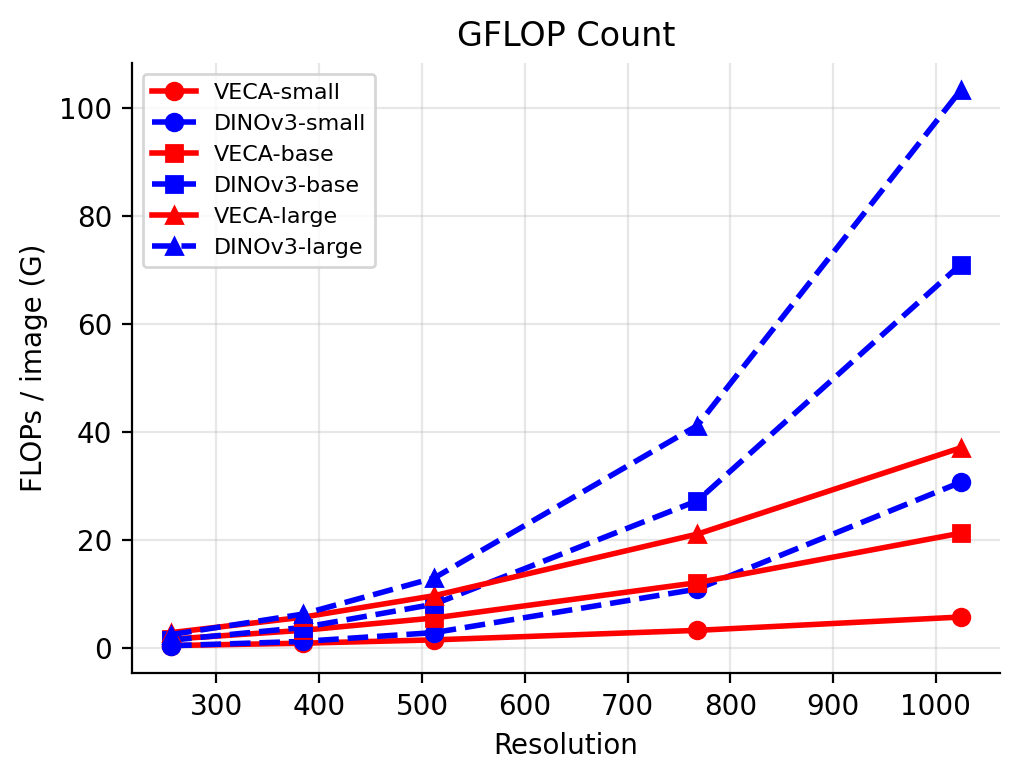

In [9]:
df = pd.read_csv("attention_block_flops_veca_vs_dinov3.csv")

markers = {"small": "o", "base": "s", "large": "^"}

fig, ax = plt.subplots(figsize=(5.2, 4.0), dpi=200)

for size in MODEL_SIZES:
    d = df[df["model_size"] == size].sort_values("resolution")

    ax.plot(
        d["resolution"],
        d["veca_flops"] / 1e9,
        color="red",
        marker=markers[size],
        linewidth=2,
        label=f"VECA-{size}",
    )

    ax.plot(
        d["resolution"],
        d["dinov3_flops"] / 1e9,
        color="blue",
        marker=markers[size],
        linestyle="--",
        linewidth=2,
        label=f"DINOv3-{size}",
    )

ax.set_title("GFLOP Count")
ax.set_xlabel("Resolution")
ax.set_ylabel("FLOPs / image (G)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("attention_block_flops_veca_vs_dinov3.pdf", bbox_inches="tight")
plt.savefig("attention_block_flops_veca_vs_dinov3.png", bbox_inches="tight")
plt.show()
